In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/main/seminars/S02/S02-hw-dataset.csv'
df = pd.read_csv(url)

In [3]:
# Первые строки
print("Первые 5 строк датасета:")
print(df.head())

# Информация о столбцах и типах
print("\nИнформация о датасете:")
print(df.info())

# Базовые описательные статистики
print("\nОписательные статистики:")
print(df.describe())

Первые 5 строк датасета:
   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB
None

Описательные статистики:
         user_id         age  purchases      revenue
count  41.000000   39.000000  41.000000    41.000000
mean   20.243902   36.512821   4.829268   820.048780
std    11.659289   18.304259   2.710189   613.1

In [4]:
# Доля пропусков в каждом столбце
missing_proportion = df.isna().mean()
print("Доля пропусков:")
print(missing_proportion)

Доля пропусков:
user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64


In [5]:
# Количество полностью дублирующих строк
duplicates_count = df.duplicated().sum()
print(f"Количество дублирующих строк: {duplicates_count}")

# Вывод дубликатов
if duplicates_count > 0:
    print("Дублирующие строки:")
    print(df[df.duplicated()])

Количество дублирующих строк: 1
Дублирующие строки:
    user_id   age country  purchases  revenue
40       10  24.0      RU          7      511


In [6]:
# Отрицательные значения в purchases
negative_purchases = df[df['purchases'] < 0]
print("Отрицательные покупки:")
print(negative_purchases)

# Нереалистичные возраста (>100)
old_age = df[df['age'] > 100]
print("\nВозраст >100:")
print(old_age)

# Возраст <10 (возможно, нереалистично для покупок)
young_age = df[df['age'] < 10]
print("\nВозраст <10:")
print(young_age)

# Покупки >0, но revenue=0 (логическое противоречие)
zero_revenue_positive_purchases = df[(df['purchases'] > 0) & (df['revenue'] == 0)]
print("\nПокупки >0, но revenue=0:")
print(zero_revenue_positive_purchases)

Отрицательные покупки:
   user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785

Возраст >100:
   user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785

Возраст <10:
    user_id  age country  purchases  revenue
20       21  5.0      RU          8     1488

Покупки >0, но revenue=0:
    user_id   age country  purchases  revenue
10       11  24.0      US          4        0


Одна строка с отрицательными покупками (-1) и возрастом 120 (user_id=6).
Одна строка с возрастом 5 и 8 покупками (user_id=21)  возможно, ошибка ввода.
Одна строка с 4 покупками, но доходом 0 (user_id=11) подозрительно, так как доход должен быть положительным.

In [7]:
# Частоты по странам
print("Частоты по странам:")
print(df['country'].value_counts())

Частоты по странам:
country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64


In [8]:
# Средний и суммарный доход/покупки по странам
groupby_country = df.groupby('country')[['revenue', 'purchases']].agg(['mean', 'sum'])
print("Агрегаты по странам:")
print(groupby_country)

Агрегаты по странам:
             revenue        purchases    
                mean    sum      mean sum
country                                  
CN       1054.000000   2108  4.500000   9
DE       1445.500000   8673  6.500000  39
FR        675.916667   8111  4.250000  51
RU        790.076923  10271  4.769231  62
US        557.375000   4459  4.625000  37


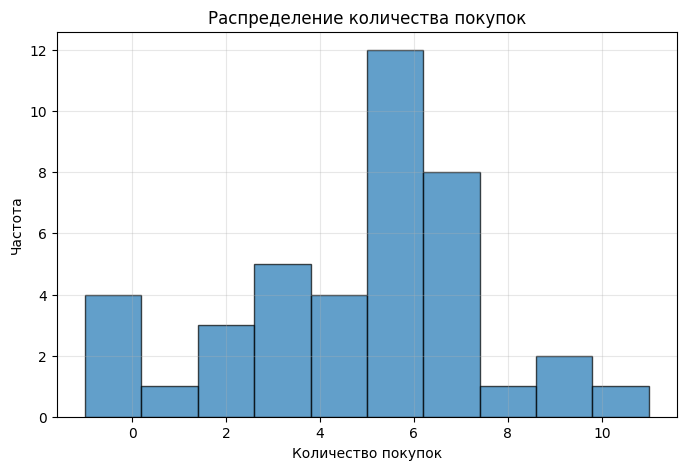

In [9]:
# Гистрограмма для количественного признака
plt.figure(figsize=(8, 5))
plt.hist(df['purchases'], bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Количество покупок')
plt.ylabel('Частота')
plt.title('Распределение количества покупок')
plt.grid(True, alpha=0.3)
plt.savefig(
    r"C:\Users\1\test\ai-group1\homeworks\HW02\figures\histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

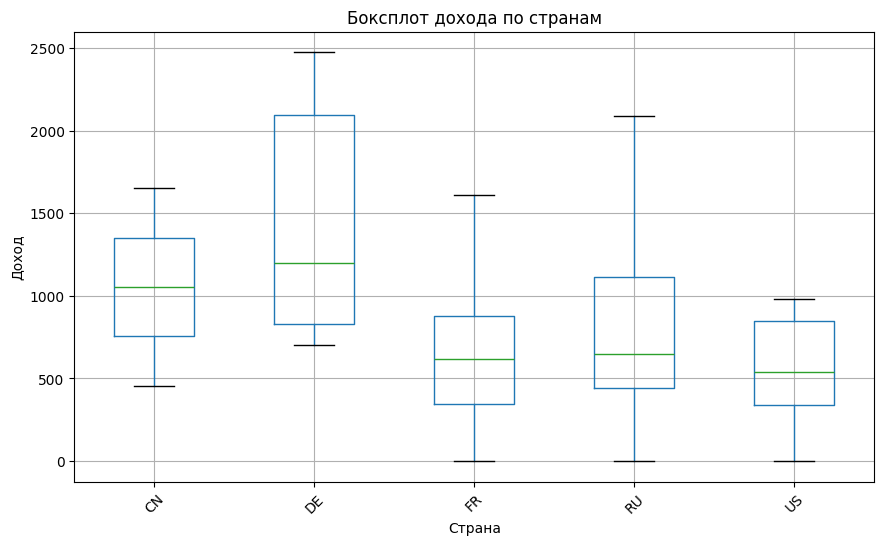

In [10]:
# Боксплот для дохода по странам
plt.figure(figsize=(10, 6))
df.boxplot(column='revenue', by='country', ax=plt.gca())
plt.title('Боксплот дохода по странам')
plt.suptitle('')  
plt.xlabel('Страна')
plt.ylabel('Доход')
plt.xticks(rotation=45)
plt.savefig(
    r"C:\Users\1\test\ai-group1\homeworks\HW02\figures\boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

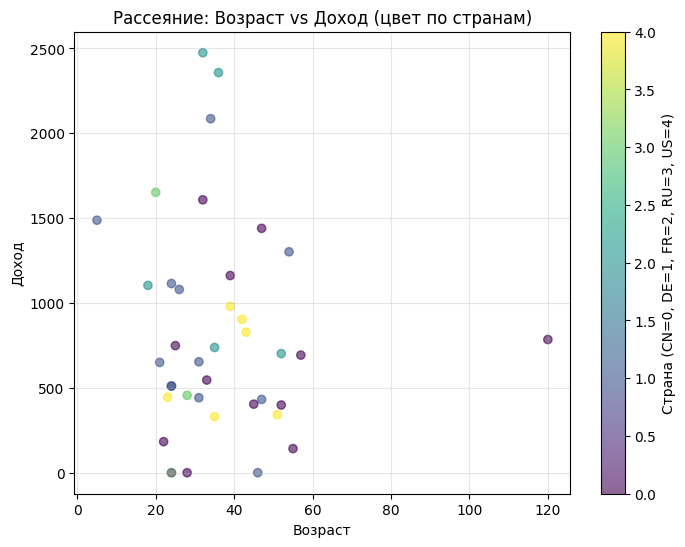

In [11]:
# Скейтерплот для несколько признаков
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['age'], df['revenue'], c=pd.factorize(df['country'])[0], alpha=0.6)
plt.xlabel('Возраст')
plt.ylabel('Доход')
plt.title('Рассеяние: Возраст vs Доход (цвет по странам)')
plt.colorbar(scatter, label='Страна (CN=0, DE=1, FR=2, RU=3, US=4)')
plt.grid(True, alpha=0.3)
plt.savefig(
    r"C:\Users\1\test\ai-group1\homeworks\HW02\figures\scatter.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()